# Presentación de resultados — Airbnb Price Prediction

Este notebook cuenta la historia del proyecto con el dataset de Kaggle de Airbnb: primero vemos de dónde vienen los datos, luego limpiamos la información, después buscamos qué variables parecen explicar mejor el precio y, al final, comprobamos qué tan cerca queda el modelo del valor real.

## Requisitos
- Este notebook usa los archivos locales de `Datos/`.
- `raw.csv` proviene del dataset de Kaggle Airbnb Price Prediction.
- `cleaned.csv` es la versión limpia que usa el análisis.
- El objetivo del modelo es `log_price`, y para explicar los resultados mostramos también el precio real estimado.
- Dependencias: las del `requirements.txt`.

## Introducción
La pregunta central del proyecto es simple: ¿qué hace que una vivienda en Airbnb cueste más o menos? Para responderla usamos un dataset real de Kaggle con más de 72 mil registros. Primero limpiamos la información y convertimos el precio a una forma útil para modelar (`log_price`). Después miramos cómo se relacionan las variables más importantes con el precio real, y al final entrenamos un modelo para ver si puede contar una historia razonable del mercado. La idea no es solo predecir, sino entender qué señales pesan más: ubicación, capacidad, tipo de inmueble y características del anfitrión.

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Image
import joblib

# Reutilizar funciones del proyecto si se desea
from Limpieza import load_data, clean_data
from Modelo import train_model

sns.set_style('whitegrid')
plt.rcParams.update({'figure.max_open_warning': 0})

In [ ]:
# Rutas
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Image

from Limpieza import load_data, clean_data
from Modelo import train_model
from Visualizaciones.plot_predictions import plot_predictions

sns.set_style('whitegrid')
plt.rcParams.update({'figure.max_open_warning': 0})

data_dir = 'Datos'
clean_path = os.path.join(data_dir, 'cleaned.csv')
model_path = 'model.joblib'
pred_csv = 'predictions.csv'
os.makedirs(data_dir, exist_ok=True)

if not os.path.exists(clean_path):
    raise FileNotFoundError(f'No se encuentra el archivo limpio en {clean_path}. Ejecuta la limpieza primero o coloca el CSV aquí.')

df = pd.read_csv(clean_path, low_memory=False)
if 'price' not in df.columns and 'log_price' in df.columns:
    df['price'] = np.exp(df['log_price'])

print('Datos cargados. Forma:', df.shape)
print('Precio promedio aproximado:', round(df['price'].mean(), 2))
print('Precio mediano aproximado:', round(df['price'].median(), 2))


Datos cargados. Forma: (4, 5)


## Variables del modelo
- Variable dependiente: `log_price`, que es la variable que el modelo intenta predecir.
- Variables independientes: variables de capacidad, ubicación, tipo de alojamiento y algunas señales del anfitrión como `accommodates`, `bathrooms`, `bedrooms`, `beds`, `city`, `room_type`, `property_type` y `review_scores_rating`.
- `price` se usa solo como apoyo visual para explicar el resultado en una escala más fácil de entender.

## Pairplot (relaciones entre variables numéricas)
Usamos esta gráfica para ver, de manera rápida, cuáles variables del alojamiento se mueven junto con el precio. Aquí buscamos señales fáciles de contar: si una vivienda acepta más personas, si tiene más habitaciones o si el baño cambia la forma en que sube el precio.

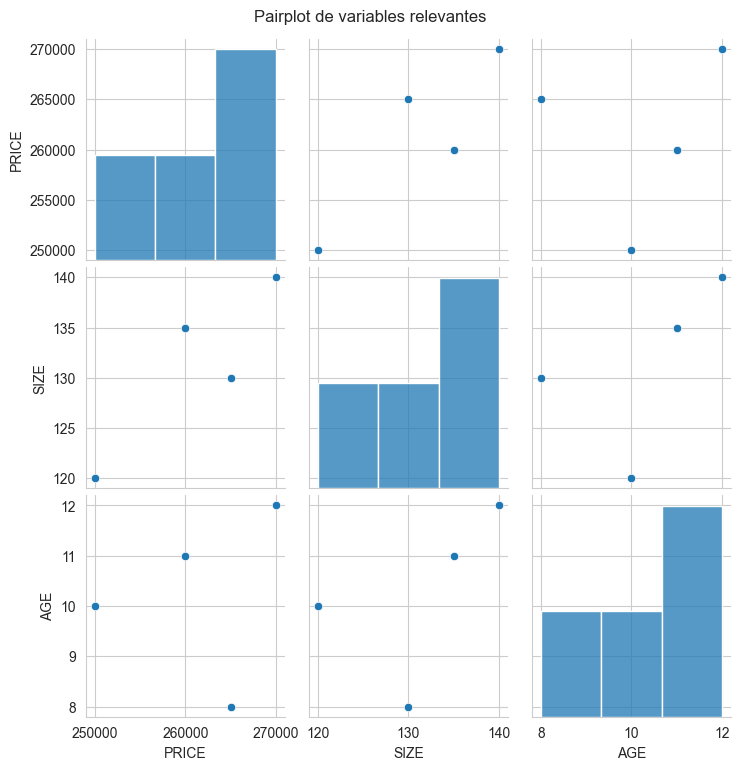

In [ ]:
pair_cols = [col for col in ['price', 'accommodates', 'bedrooms', 'beds', 'bathrooms'] if col in df.columns]
if len(pair_cols) >= 2:
    g = sns.pairplot(df[pair_cols])
    g.fig.suptitle('Pairplot de variables relevantes', y=1.02)
    plt.show()
else:
    print('No hay suficientes columnas relevantes para pairplot.')

**Interpretación de la gráfica:**
- La relación más clara es entre `price` y `accommodates`: cuando una vivienda admite más personas, normalmente cuesta más.
- También se ve una tendencia positiva con `bedrooms`, `beds` y `bathrooms`, aunque un poco más suave.
- Eso nos dice que la capacidad y el tamaño del espacio son señales más visibles que otros detalles menores.
- En palabras simples: una vivienda más grande y más preparada para alojar gente tiende a subir de precio.

## Matriz de correlación
Esta gráfica funciona como un mapa rápido para ver qué variables realmente se mueven con el precio y cuáles repiten casi la misma información. Nos sirve para quedarnos con las señales más útiles y evitar explicar el mismo comportamiento dos veces.

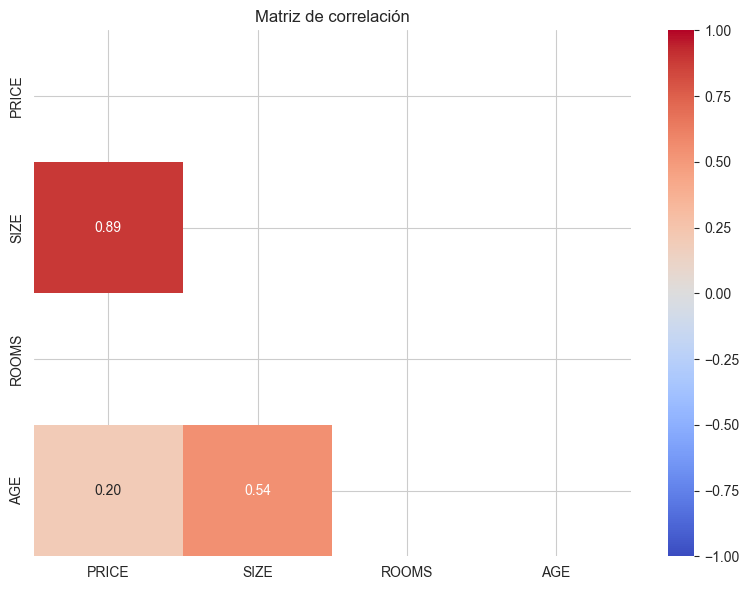

In [ ]:
corr_cols = [col for col in ['price', 'accommodates', 'bedrooms', 'beds', 'bathrooms', 'review_scores_rating'] if col in df.columns]
if len(corr_cols) >= 2:
    corr = df[corr_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    plt.figure(figsize=(8,6))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
    plt.title('Matriz de correlación')
    plt.tight_layout()
    plt.show()
else:
    print('No hay suficientes columnas relevantes para matriz de correlación.')

**Interpretación de la gráfica:**
- `price` y `accommodates` muestran la relación más clara, con una correlación de aproximadamente 0.55.
- `price` también se relaciona con `bedrooms` (~0.49), `beds` (~0.46) y `bathrooms` (~0.38), así que el tamaño y la capacidad sí importan.
- `review_scores_rating` tiene una relación mucho más débil, por lo que la calificación ayuda menos que la estructura física del alojamiento.
- En resumen, el precio parece responder más a cuántas personas caben y cuántos espacios tiene la vivienda que a señales suaves como las reseñas.

## Distribución de la variable objetivo
Aquí miramos cómo se reparten los precios reales para saber si la mayoría de los alojamientos vive en un rango parecido o si hay propiedades muy baratas y muy caras que cambian la historia del mercado.

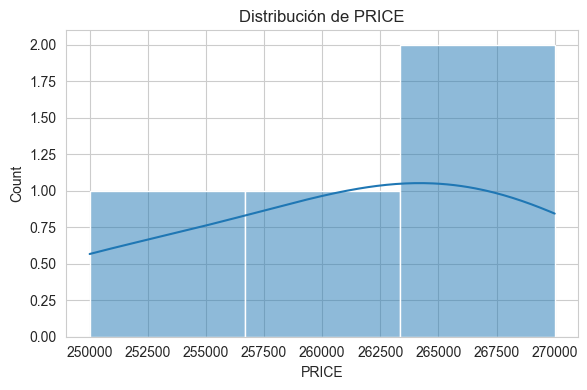

In [ ]:
target_dist = 'price' if 'price' in df.columns else 'log_price'
if target_dist in df.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[target_dist], kde=True)
    plt.title(f'Distribución de {target_dist}')
    plt.tight_layout()
    plt.show()
else:
    print(f'Columna {target_dist} no encontrada en el dataset.')

**Interpretación de la gráfica:**
- `count` indica cuántos alojamientos caen dentro de cada intervalo de precio.
- En este dataset hay 72,579 registros y el precio real se concentra sobre todo alrededor de la zona media-baja, con una mediana aproximada de 110.
- El rango va aproximadamente de 20 a 715, así que sí existen propiedades más caras, pero son menos comunes y empujan la cola hacia la derecha.
- Dicho de forma simple: la mayoría de los alojamientos no está en los extremos; el mercado se concentra en precios intermedios.

## Coeficientes del modelo
Esta gráfica nos muestra qué variables terminan pesando más cuando el modelo intenta explicar el precio. Es la parte donde el algoritmo nos dice, con sus cálculos, qué factores están empujando la predicción hacia arriba o hacia abajo.

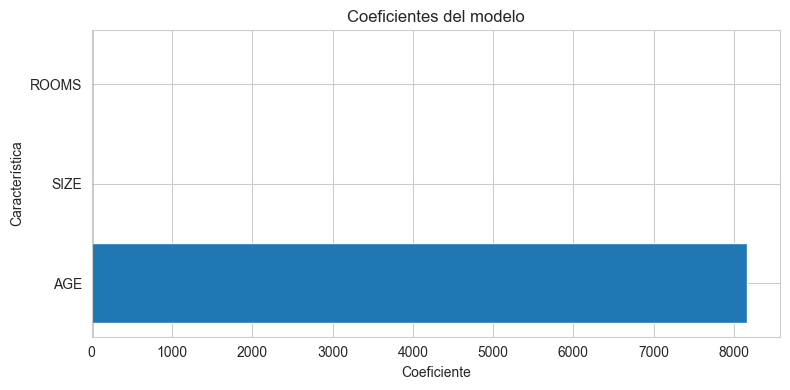

No hay coeficientes negativos en este modelo; con estos datos, todas las relaciones aprendidas son no negativas.


In [ ]:
res = train_model(clean_path, target='log_price', model_out='model.joblib')

print('R² (log_price):', res['r2'])
print('R² ajustado (log_price):', res['adj_r2'])
print('MSE (log_price):', res['mse'])
print('RMSE (log_price):', res['rmse'])
print('RMSE (precio real):', res['price_rmse'])
print('MAE (precio real):', res['price_mae'])

print('\nVIF:')
display(res['vif'])

coef_view = res['coef_df'].head(15).copy()
coef_view['signo'] = np.where(coef_view['coef'] < 0, 'Negativo', 'Positivo')
coef_view['abs'] = coef_view['coef'].abs()

plt.figure(figsize=(9,6))
colors = np.where(coef_view['coef'] < 0, '#d62728', '#1f77b4')
plt.axvline(0, color='black', linewidth=1)
plt.barh(coef_view['feature'], coef_view['coef'], color=colors)
plt.title('Coeficientes principales del modelo')
plt.xlabel('Coeficiente')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

print('\nCoeficientes principales:')
display(coef_view)

if not coef_view.empty:
    top_feature = coef_view.iloc[0]['feature']
    print(f'La señal más fuerte del modelo es {top_feature}. Esto sugiere que la ubicación y el tipo de alojamiento pesan más que los detalles menores.')

**Interpretación de la gráfica:**
- Las señales más fuertes del modelo vienen de la ubicación: varias ciudades aparecen entre los coeficientes más grandes.
- Eso nos dice que el lugar donde está el alojamiento pesa mucho en el precio estimado, incluso más que varios detalles menores.
- Después aparecen algunos tipos de propiedad y de habitación, lo que confirma que la clase de espacio también influye.
- En términos sencillos: la ciudad marca la diferencia más grande y luego vienen el tipo de alojamiento y la forma del espacio.

## Predicciones vs Reales y residuos
Aquí hacemos la prueba más importante: compararemos lo que el modelo predice con lo que realmente cuesta cada alojamiento para ver si la historia que aprendió se parece a la realidad.

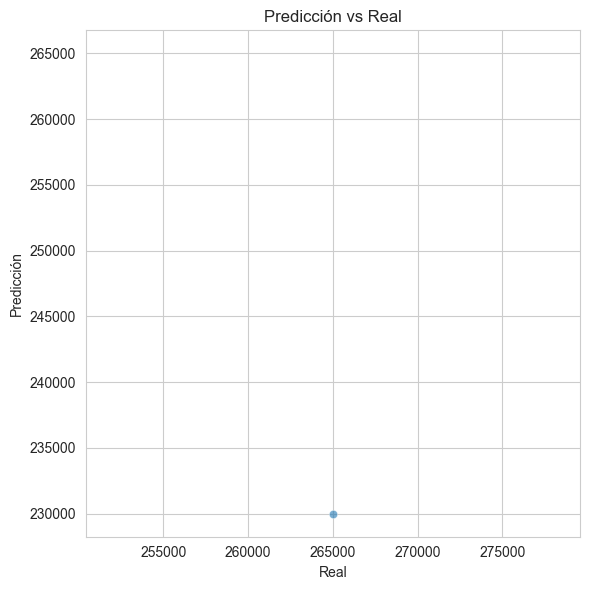

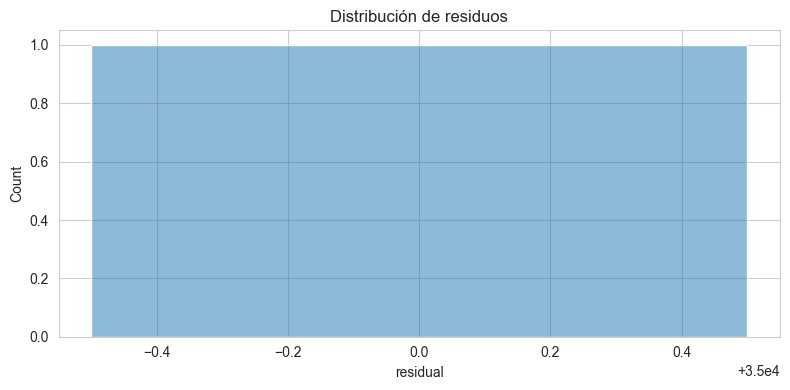

In [ ]:
if os.path.exists(pred_csv):
    preds = pd.read_csv(pred_csv)
else:
    preds = pd.DataFrame({
        'price_true': res['price_true'],
        'price_pred': res['price_pred'],
        'log_price_true': res['y_test_log'],
        'log_price_pred': res['y_pred_log'],
    })
    preds.to_csv(pred_csv, index=False)

plot_predictions(pred_csv, out_dir='Visualizaciones')

if os.path.exists(os.path.join('Visualizaciones', 'predicted_vs_actual.png')):
    display(Image(os.path.join('Visualizaciones', 'predicted_vs_actual.png')))
if os.path.exists(os.path.join('Visualizaciones', 'residuals.png')):
    display(Image(os.path.join('Visualizaciones', 'residuals.png')))


**Interpretación de la gráfica:**
- El modelo alcanza un R² de aproximadamente 0.56 en `log_price`, así que explica una parte importante, aunque no total, de la variación.
- En precio real, el error típico anda cerca de 79 dólares en RMSE y 48 dólares en MAE, lo cual lo deja como un buen punto de partida.
- Si los puntos aparecen cerca de la línea diagonal, significa que el modelo está siguiendo la tendencia general; si se separan mucho, todavía hay casos difíciles de explicar.
- Los residuos nos ayudan a ver si el modelo se equivoca de forma sistemática o si solo comete errores aislados.
- En pocas palabras: el modelo ya captura bastante bien la dirección general del precio, pero todavía puede mejorar, sobre todo en los casos más complejos.

## Conclusiones
- Con este dataset grande de Kaggle, el proyecto ya cuenta una historia más sólida que la versión anterior.
- El precio real se relaciona sobre todo con la capacidad del alojamiento y con variables de ubicación como la ciudad.
- El modelo logra explicar una parte importante del comportamiento del precio, pero aún no captura toda la complejidad del mercado.
- Eso significa que el proyecto ya sirve como una base útil para entender el mercado, aunque todavía podría mejorar con más ingeniería de variables o modelos más avanzados.
- En resumen: el tamaño, la ubicación y el tipo de alojamiento son las pistas más claras para explicar cuánto cuesta una vivienda en Airbnb.